<a href="https://colab.research.google.com/github/jithin675/Data-Science-projects/blob/main/Earthquake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import warnings

In [2]:
df=pd.read_csv('/content/earthquake_data_tsunami.csv')

In [3]:
df


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,7.7,0,8,912,427,0.000,0.0,60.000,13.0490,-88.660,2001,1,0
778,6.9,5,7,745,0,0.000,0.0,36.400,56.7744,-153.281,2001,1,0
779,7.1,0,7,776,372,0.000,0.0,103.000,-14.9280,167.170,2001,1,0
780,6.8,0,5,711,64,0.000,0.0,33.000,6.6310,126.899,2001,1,0


In [4]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [6]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


Q1: What is the distribution of earthquake magnitudes, and how has the number of recorded events trended over the years?


Recently yearly counts:
Year
2018    43
2019    33
2020    27
2021    42
2022    40
Name: count, dtype: int64


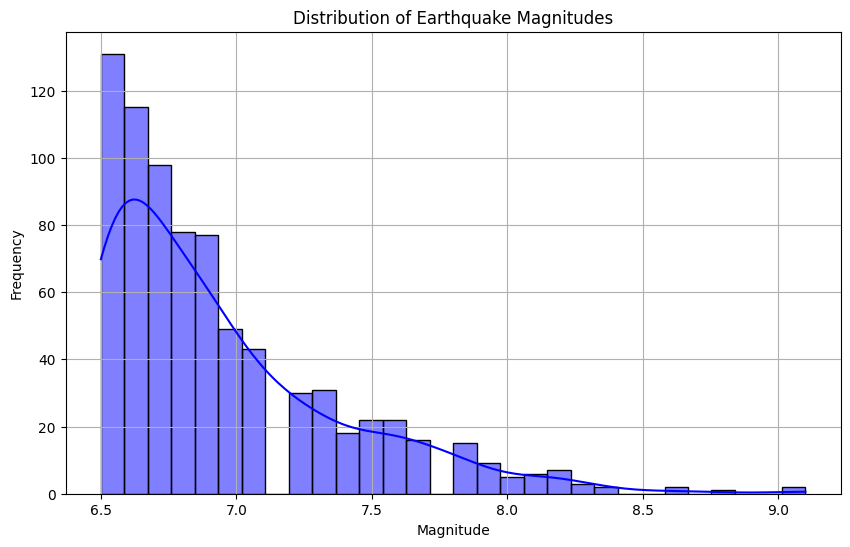

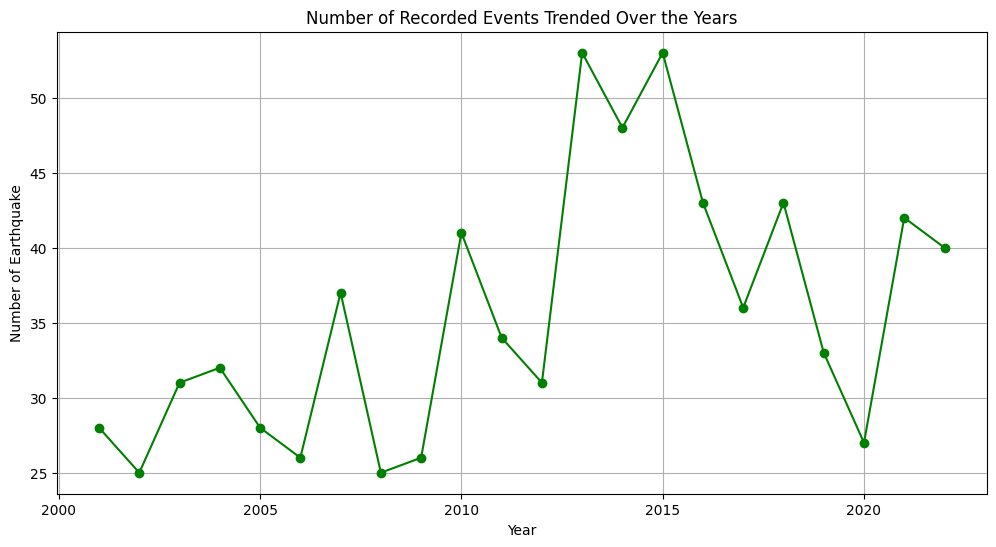

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['magnitude'], bins=30, kde=True, color='blue')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('magnitude_distribution.png')


yearly_counts = df['Year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
yearly_counts.plot(kind='line', marker='o',color='green')
plt.title('Number of Recorded Events Trended Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Earthquake')
plt.grid(True)
plt.savefig('yearly_earthquake_trend.png')
print(f"\nRecently yearly counts:\n{yearly_counts.tail()}")

Q2: What is the average magnitude and depth for earthquakes that did cause a tsunami versus those that did not?

In [8]:
tsunami_comparison = df.groupby('tsunami').agg(
    avg_magnitude=('magnitude', 'mean'),
    avg_depth=('depth', 'mean'),
    avg_sig=('sig', 'mean'),
    count=('tsunami', 'size')
)
print("Comparison of Average (Tsunami 1=Yes, 0=No):")
print(tsunami_comparison)

Comparison of Average (Tsunami 1=Yes, 0=No):
         avg_magnitude  avg_depth     avg_sig  count
tsunami                                             
0             6.942803  69.667356  874.092050    478
1             6.938487  85.656796  863.845395    304



Saved 'tsunami_magnitude_boxplot.png'


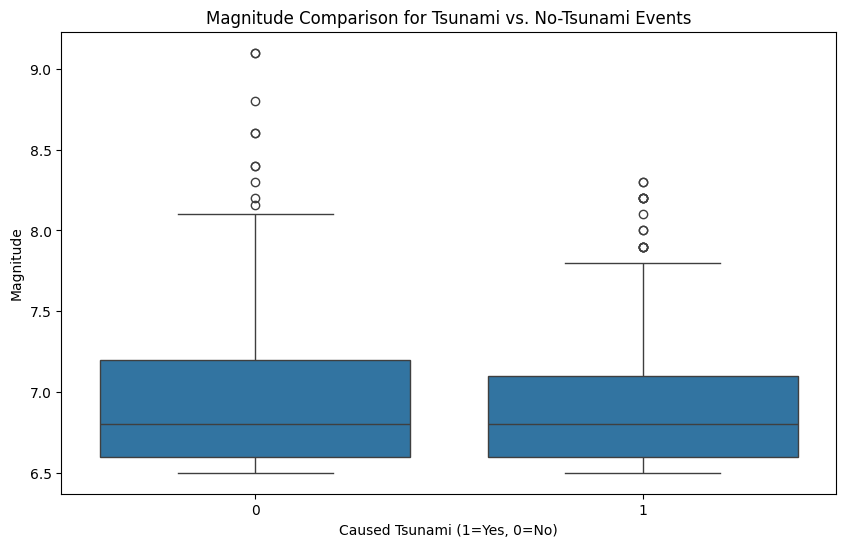

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='tsunami', y='magnitude', data=df)
plt.title('Magnitude Comparison for Tsunami vs. No-Tsunami Events')
plt.xlabel('Caused Tsunami (1=Yes, 0=No)')
plt.ylabel('Magnitude')
plt.savefig('tsunami_magnitude_boxplot.png')
print("\nSaved 'tsunami_magnitude_boxplot.png'")

Q3: Which features (like magnitude, depth, mmi) are most strongly correlated with the earthquake's significance (sig)?

Correlation with Earthquake Significance ('sig'):
sig          1.000000
magnitude    0.515871
cdi          0.479788
mmi          0.442423
latitude     0.204306
Year         0.124439
gap          0.114285
tsunami     -0.015500
Month       -0.029189
nst         -0.030100
depth       -0.088667
dmin        -0.095318
longitude   -0.190132
Name: sig, dtype: float64

Saved 'correlation_heatmap.png'


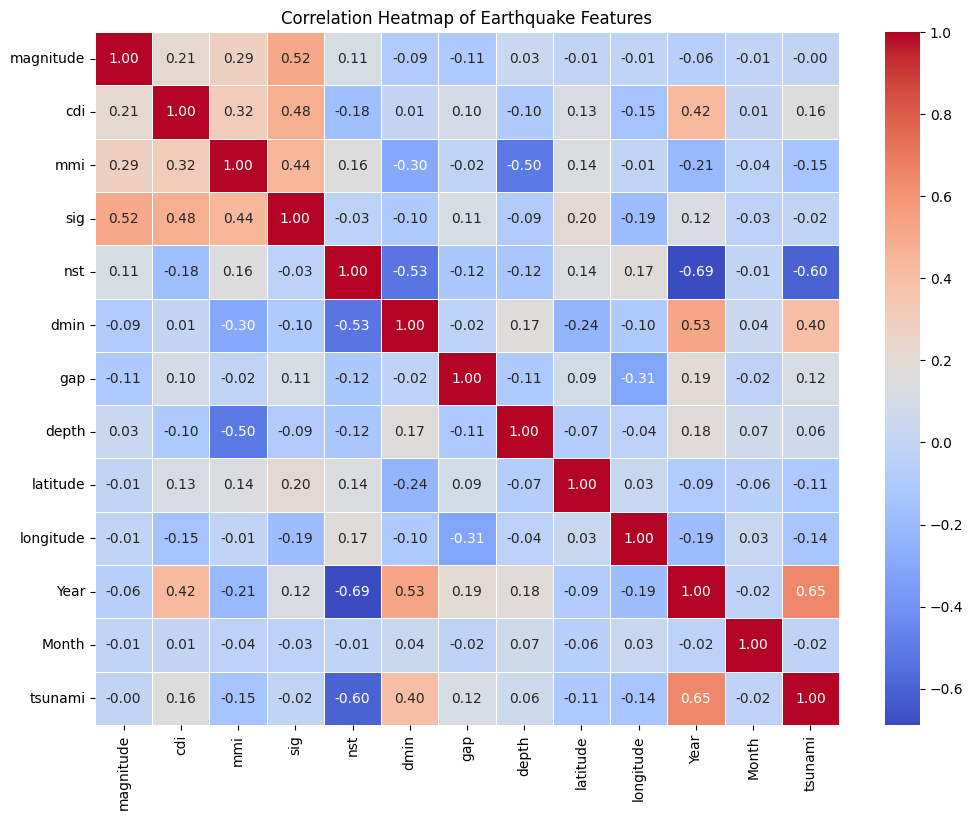

In [15]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()




sig_correlation = correlation_matrix['sig'].sort_values(ascending=False)
print("Correlation with Earthquake Significance ('sig'):")
print(sig_correlation)




plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Earthquake Features')
plt.savefig('correlation_heatmap.png')
print("\nSaved 'correlation_heatmap.png'")

Q4: Predict if an earthquake will cause a tsunami

In [19]:
x= ['magnitude', 'depth', 'sig', 'mmi', 'cdi', 'nst']
y= 'tsunami'

X_train, X_test, y_train, y_test = train_test_split(df[x], df[y], test_size=0.3, random_state=42)


In [22]:
model=LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [23]:
y_pred=model.predict(X_test)

In [25]:
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred, target_names=['No Tsunami (0)', 'Tsunami (1)']))

Accuracy: 0.8212765957446808
                precision    recall  f1-score   support

No Tsunami (0)       0.92      0.76      0.83       138
   Tsunami (1)       0.73      0.91      0.81        97

      accuracy                           0.82       235
     macro avg       0.82      0.83      0.82       235
  weighted avg       0.84      0.82      0.82       235

